In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '.')

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "lines.linewidth": 1.5,
})

In [2]:
# -----------------------------------------
# Grid
# -----------------------------------------
N = 100
L = 1
dx = L / N
Np1 = N + 1
i = np.arange(1, N + 1)
x_center = (i - 0.5) / N
i = np.arange(0, Np1)
x_nodes = i * dx

Nr = 10
Nrp2 = Nr + 2
i = np.arange(0, Nrp2)
dx_obs = L / (Nr + 1)
ratio_obs_to_discritization = int(dx_obs / dx)
x_nodes_rec = i * dx_obs
recv_idx = (i * ratio_obs_to_discritization)[1:-1]
x_recv = x_nodes[recv_idx]

Nsol, Nobs = 100, 10
data_dir = "./../../Data/Experiment7/"

In [3]:
iterations_to_load = [-6, -4, -1]

In [4]:
results = {}

for it in iterations_to_load:
    ws_path   = data_dir + f"wavespeed_statistics_iteration-{it}CMTrue.npz"
    wave_path = data_dir + f"wave_iteration{it}.npz"

    ws   = np.load(ws_path)
    wave = np.load(wave_path)

    # levelset-thresholded latent mean and bands (on x_spatial, 100 pts)
    pcn_c_mean  = ws["pcn_c_mean"]
    pcn_c_upper = ws["pcn_c_upper"]
    pcn_c_lower = ws["pcn_c_lower"]

    push_c_mean  = ws["push_c_mean"]
    push_c_upper = ws["push_c_upper"]
    push_c_lower = ws["push_c_lower"]

    x_spatial = ws["x_spatial"]
    x_nodes_  = ws["x_nodes"]
    c_true    = ws["c_true"]

    y_dagger = wave["y_obs"].reshape(Nobs, 1)

    results[it] = dict(
        pcn_c_mean=pcn_c_mean,
        pcn_c_upper=pcn_c_upper,
        pcn_c_lower=pcn_c_lower,
        push_c_mean=push_c_mean,
        push_c_upper=push_c_upper,
        push_c_lower=push_c_lower,
        x_spatial=x_spatial,
        x_nodes=x_nodes_,
        c_true=c_true,
        y_dagger=y_dagger,
    )

print("Loaded iterations:", list(results.keys()))

Loaded iterations: [-6, -4, -1]


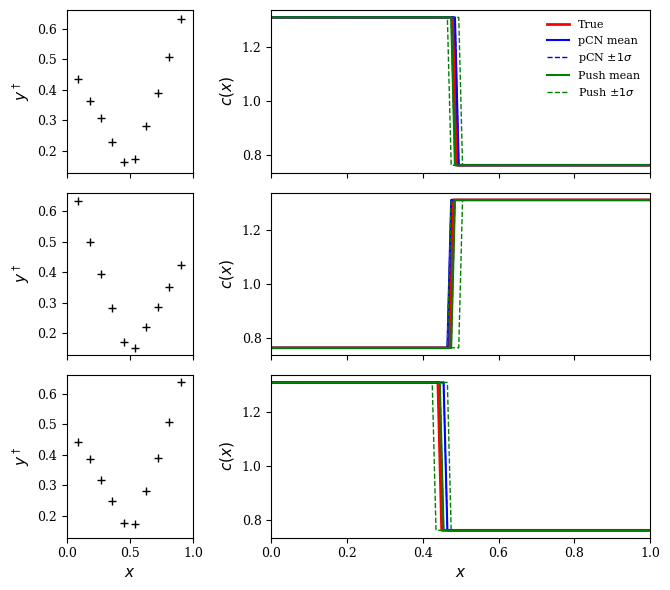

In [5]:
n_rows = len(results)
fig, axes = plt.subplots(n_rows, 2,
                         figsize=(6.8, 2.0 * n_rows),
                         gridspec_kw={"width_ratios": [1, 3]})

obs_all = np.concatenate([data["y_dagger"].ravel() for data in results.values()])
obs_ylim = (obs_all.min() - 0.05 * np.ptp(obs_all),
            obs_all.max() + 0.05 * np.ptp(obs_all))

c_all = np.concatenate([
    np.concatenate([
        data["c_true"],
        data["pcn_c_upper"],
        data["pcn_c_lower"],
        data["push_c_upper"],
        data["push_c_lower"],
    ])
    for data in results.values()
])
c_ylim = (c_all.min() - 0.05 * np.ptp(c_all),
          c_all.max() + 0.05 * np.ptp(c_all))

for row, (it, data) in enumerate(results.items()):
    ax_obs  = axes[row, 0]
    ax_main = axes[row, 1]
    first_row = (row == 0)

    # Left: observations
    ax_obs.plot(x_recv, data["y_dagger"], "+", color="k")
    ax_obs.set_ylabel(r"$y^\dagger$")
    ax_obs.set_xlim([0, 1])
    ax_obs.set_ylim(obs_ylim)
    if row < n_rows - 1:
        ax_obs.set_xticklabels([])
    else:
        ax_obs.set_xlabel(r"$x$")

    xs  = data["x_spatial"]
    xn  = data["x_nodes"]

    # Right: levelset-thresholded latent mean and bands
    ax_main.plot(xn,  data["c_true"],        'r-',  lw=2, label="True" if first_row else "_")
    ax_main.plot(xs,  data["pcn_c_mean"],    'b-',        label="pCN mean" if first_row else "_")
    ax_main.plot(xs,  data["pcn_c_upper"],   'b--', lw=1, label=r"pCN $\pm1\sigma$" if first_row else "_")
    ax_main.plot(xs,  data["pcn_c_lower"],   'b--', lw=1)
    ax_main.plot(xs,  data["push_c_mean"],   'g-',        label="Push mean" if first_row else "_")
    ax_main.plot(xs,  data["push_c_upper"],  'g--', lw=1, label=r"Push $\pm1\sigma$" if first_row else "_")
    ax_main.plot(xs,  data["push_c_lower"],  'g--', lw=1)

    ax_main.set_ylabel(r"$c(x)$")
    ax_main.set_xlim([0, 1])
    ax_main.set_ylim(c_ylim)
    if row < n_rows - 1:
        ax_main.set_xticklabels([])
    else:
        ax_main.set_xlabel(r"$x$")

    if first_row:
        ax_main.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.savefig("./../../Figs/Experiment7/wavespeed_latent_all_iterations_scaled.png", dpi=300, bbox_inches='tight')
plt.show()